# Geodemographic Clustering Case Study

Demonstrates that learned embeddings (100D) can be used for geodemographic classification.
Creates 8-cluster classifications from AE and PCA embeddings, evaluates cluster quality.

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import clustergram
import joblib
import pickle

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, 
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    v_measure_score
)

import warnings
warnings.filterwarnings('ignore')

## Configuration

In [ ]:
# Parameters
target_dim = 64
n_clusters = 8  # Match OAC supergroups
n_inits = 100   # Must match 6a
random_seed = 20210321

# Paths
data_path = "../AE_outputs/engcensus_all/"
working_dir = data_path + "250epoch_scan_lin"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
geo_path = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
oac_path = "../data/OAC/OAC_assignment.csv"

# Stability checkpoint path (for median run embeddings)
stability_path = f"../AE_outputs/retraining_stability/data/stability_checkpoint_{target_dim}d.pkl"

# Output - use median run directory (consistent with 6a)
output_dir = "./plots/geodemo_clustering_median_run/"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/data", exist_ok=True)

print(f"Creating {n_clusters} clusters from {target_dim}D embeddings (MEDIAN RUN)")
print(f"Random seed: {random_seed}")
print(f"n_inits: {n_inits}")

## Load Data

In [ ]:
# Load original census data
print("Loading census data...")
df_census = pd.read_parquet(cleaned_data_path)
df_census = df_census.set_index('OA')
print(f"Census data: {df_census.shape}")

# Load PCA embeddings (compute on the fly - deterministic)
print(f"\nComputing PCA {target_dim}D embeddings...")
pca = PCA(n_components=target_dim, random_state=random_seed)
pca_embeddings = pca.fit_transform(df_census)
pca_latent_df = pd.DataFrame(pca_embeddings, index=df_census.index)
print(f"PCA embeddings: {pca_latent_df.shape}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Load AE embeddings from stability checkpoint (MEDIAN RUN)
print(f"\nLoading stability checkpoint from: {stability_path}")
with open(stability_path, 'rb') as f:
    checkpoint = pickle.load(f)

embeddings_list = checkpoint['embeddings_list']
reco_errors_list = checkpoint['reco_errors_list']
n_runs = checkpoint['n_runs']
print(f"Loaded {n_runs} runs from stability checkpoint")

# Find the median run (by overall RMSE)
rmse_per_run = []
for run_idx, reco_err in enumerate(reco_errors_list):
    rmse = np.sqrt(reco_err.mean()) * 100
    rmse_per_run.append(rmse)

rmse_per_run = np.array(rmse_per_run)
median_rmse = np.median(rmse_per_run)
median_run_idx = np.argmin(np.abs(rmse_per_run - median_rmse))

print(f"\nMedian RMSE: {median_rmse:.4f}%")
print(f"Median run index: {median_run_idx} (RMSE = {rmse_per_run[median_run_idx]:.4f}%)")

# Get median run embeddings
ae_embeddings = embeddings_list[median_run_idx]
ae_latent_df = pd.DataFrame(ae_embeddings, index=df_census.index)
print(f"\nAE embeddings (median run): {ae_latent_df.shape}")

# Load OAC
print(f"\nLoading OAC classifications...")
oac = pd.read_csv(oac_path)
oac = oac[['Geography_Code', 'Supergroup8']].rename(columns={'Geography_Code': 'OA'})
oac = oac.set_index('OA')
oac = oac.reindex(df_census.index)
print(f"OAC: {oac.shape}")
print(f"OAC Supergroups: {oac['Supergroup8'].nunique()} unique groups")

In [ ]:
# Load the kmeans clustering results for AE and PCA embeddings
clustering_file = f"{output_dir}/data/cluster_assignments_{target_dim}d_k{n_clusters}_n{n_inits}.csv"
pca_model_file = f"{output_dir}/data/kmeans_pca_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"
ae_model_file = f"{output_dir}/data/kmeans_ae_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"

print(f"Loading clustering results from {clustering_file}...")
clusters_df = pd.read_csv(clustering_file, index_col=0)
kmeans_pca = joblib.load(pca_model_file)
kmeans_ae = joblib.load(ae_model_file)

pca_clusters = clusters_df['pca_cluster'].values
ae_clusters = clusters_df['ae_cluster'].values

print(f"Loaded {len(clusters_df)} cluster assignments")
print(f"KMeans models loaded from {pca_model_file} and {ae_model_file}")

In [5]:
# clusters_df["ae_cluster"]=clusters_df["ae_cluster"]+1


# #remap the cluster IDs to to old version, for consistency in colours
# mapping_ae = {6:1,
#               7:3,
#               4:7,
#               1:5,
#               2:2,
#               3:4,
#               5:8,
#               8:6 }

# clusters_df["ae_cluster"]=clusters_df["ae_cluster"].map(mapping_ae)

In [6]:
# Step 1: Load geometries
print("Loading geometries for mapping...")
geofiles_dir = "../data/geofiles"
gdf = gpd.read_file(f"{geofiles_dir}/Output_Areas_2021_EW_BGC_V2_-5587136561181621407.gpkg")
gdf = gdf[['OA21CD', 'geometry']].rename(columns={'OA21CD': 'OA'})
gdf = gdf.set_index('OA')
# Merge with clusters
gdf = gdf.join(clusters_df)
print(f"GeoDataFrame: {gdf.shape}")

# Load London boundary for plotting
print("Loading London boundary...")
lads_gdf = gpd.read_file(f"{geofiles_dir}/Local_Authority_Districts_December_2022_UK_BGC_V2_5759908710055972638.gpkg")
london_boundary = lads_gdf[lads_gdf['LAD22CD'].str.startswith('E09')].dissolve()
if london_boundary.crs != gdf.crs:
    london_boundary = london_boundary.to_crs(gdf.crs)

# Load England/Wales boundary for plotting
print("Loading country boundaries...")
countries_gdf = gpd.read_file(f"{geofiles_dir}/Countries_December_2022_UK_BGC_1943732719298389253.gpkg")
eng_wales_gdf = countries_gdf[countries_gdf['CTRY22CD'].str.startswith(('E', 'W'))]
if eng_wales_gdf.crs != gdf.crs:
    eng_wales_gdf = eng_wales_gdf.to_crs(gdf.crs)

print("✓ All geometries loaded")

Loading geometries for mapping...
GeoDataFrame: (188880, 4)
Loading London boundary...
Loading country boundaries...
✓ All geometries loaded



Creating publication-quality map...


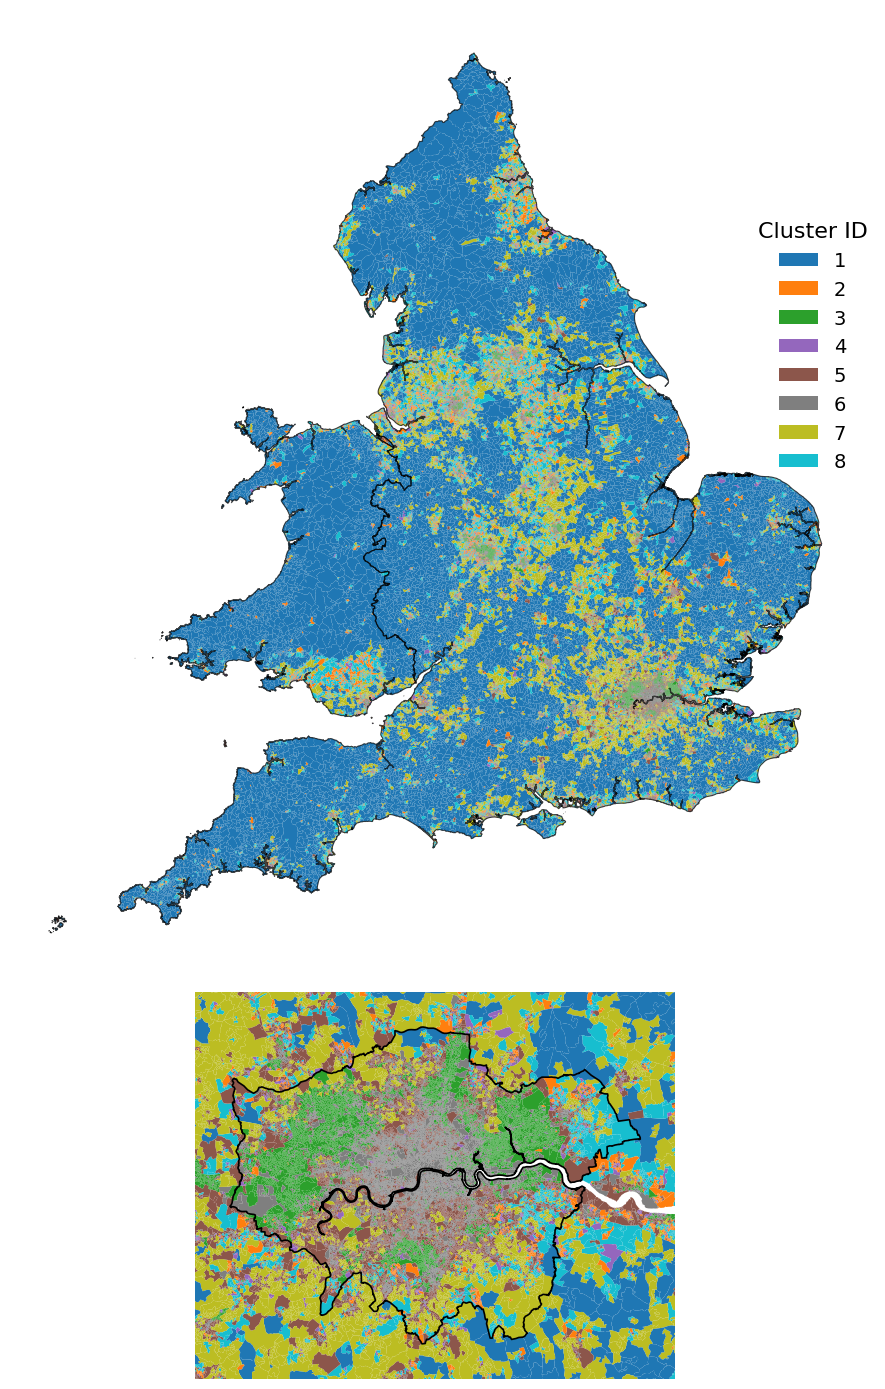

✓ Saved publication-quality map to ./plots/geodemo_clustering//publication_map_ae_64d.png


In [7]:

# Step 2: Create the map
print("\nCreating publication-quality map...")

# London bounds with buffer (IN METERS - EPSG:27700)
minx, miny, maxx, maxy = london_boundary.total_bounds
buffer = 5000  # 5km buffer
london_bounds = {
    'minx': minx - buffer, 
    'maxx': maxx + buffer, 
    'miny': miny - buffer, 
    'maxy': maxy + buffer
}

# Filter London data
gdf_london = gdf.cx[london_bounds['minx']:london_bounds['maxx'], 
                    london_bounds['miny']:london_bounds['maxy']]

# Stacked figure with height ratios
fig, axes = plt.subplots(2, 1, figsize=(10, 14), 
                         gridspec_kw={'height_ratios': [2.5, 1]})
ax_uk = axes[0]
ax_ldn = axes[1]

# Color map
cmap = plt.cm.get_cmap('tab10', n_clusters)

# === UK Map ===
gdf.plot(column='ae_cluster', ax=ax_uk, cmap=cmap,
         linewidth=0, edgecolor='none', legend=False)
eng_wales_gdf.boundary.plot(ax=ax_uk, linewidth=0.8, edgecolor='black', alpha=0.7)
ax_uk.axis('off')

# === London Map ===
gdf_london.plot(column='ae_cluster', ax=ax_ldn, cmap=cmap,
                linewidth=0, edgecolor='none', legend=False)
london_boundary.boundary.plot(ax=ax_ldn, linewidth=1.2, edgecolor='black')
ax_ldn.set_xlim(london_bounds['minx'], london_bounds['maxx'])
ax_ldn.set_ylim(london_bounds['miny'], london_bounds['maxy'])
ax_ldn.set_aspect('equal')
ax_ldn.axis('off')

# Add borders
for ax in [ax_uk, ax_ldn]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

# Legend - higher, no frame
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap(i-1), label=str(i)) 
                   for i in range(1, n_clusters + 1)]
fig.legend(handles=legend_elements, loc='upper right', ncol=1,
           fontsize=14, frameon=False, title='Cluster ID', title_fontsize=16,
           bbox_to_anchor=(0.95, 0.85))

plt.tight_layout()
plt.savefig(f"{output_dir}/publication_map_ae_{target_dim}d.png", 
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f"✓ Saved publication-quality map to {output_dir}/publication_map_ae_{target_dim}d.png")

Creating publication-quality AE cluster vs OAC overlap visualisation...



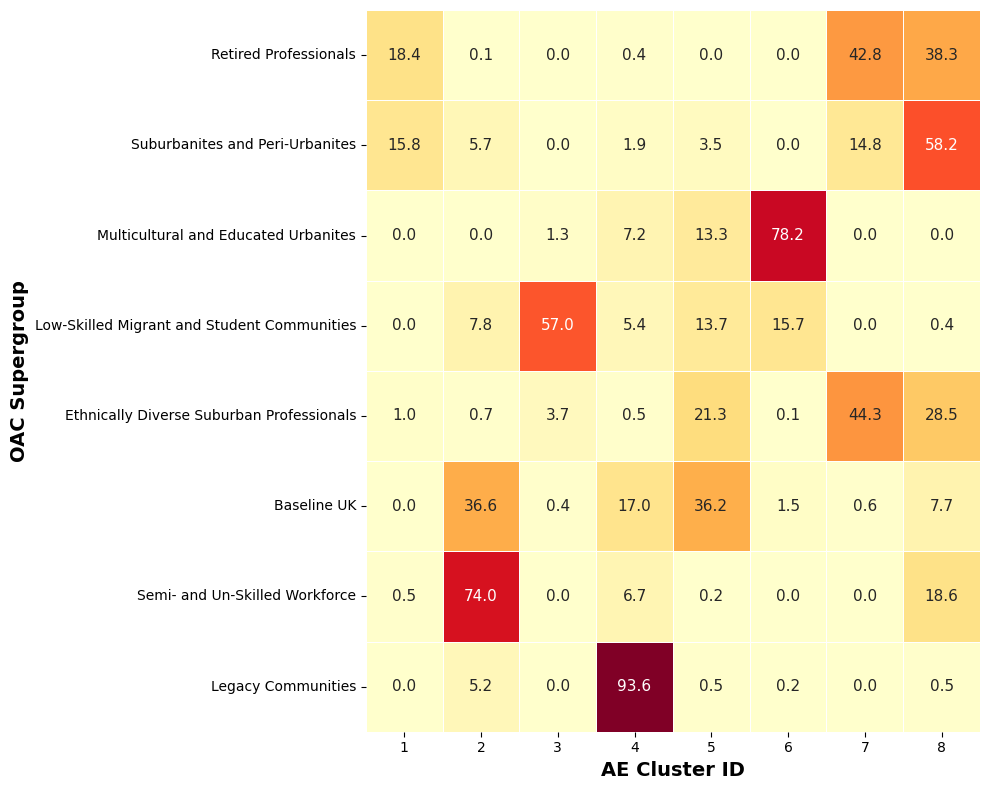

Saved heatmap to ./plots/geodemo_clustering//ae_oac_overlap_publication_64d.png
Saved table to ./plots/geodemo_clustering//


In [8]:
# Publication-quality AE cluster vs OAC overlap analysis
print("Creating publication-quality AE cluster vs OAC overlap visualisation...\n")

# OAC Supergroup names
oac_names = {
    1: "Retired Professionals",
    2: "Suburbanites and Peri-Urbanites",
    3: "Multicultural and Educated Urbanites",
    4: "Low-Skilled Migrant and Student Communities",
    5: "Ethnically Diverse Suburban Professionals",
    6: "Baseline UK",
    7: "Semi- and Un-Skilled Workforce",
    8: "Legacy Communities"
}

# Recompute overlap for AE only with nice labels
def cluster_oac_overlap_named(cluster_labels, oac_labels, oac_names):
    """Return count and percentage matrices with named OAC labels."""
    valid_mask = ~pd.isna(oac_labels)
    oac_valid = oac_labels[valid_mask]
    clusters_valid = cluster_labels[valid_mask] + 1  # Fix: add 1 to convert 0-indexed to 1-indexed
    
    oac_ids = list(range(1, n_clusters + 1))
    cluster_ids = list(range(1, n_clusters + 1))
    
    counts = pd.crosstab(oac_valid, clusters_valid)
    counts = counts.reindex(index=oac_ids, columns=cluster_ids, fill_value=0)
    
    # Rename index to OAC names
    counts.index = [oac_names[i] for i in counts.index]
    counts.columns = [str(i) for i in counts.columns]
    
    # Row-wise percentages: for each OAC, what % falls into each AE cluster
    percentages = counts.divide(counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
    percentages = percentages.fillna(0)
    
    return counts, percentages

ae_counts_named, ae_percent_named = cluster_oac_overlap_named(
    clusters_df['ae_cluster'].values, oac['Supergroup8'].values, oac_names
)

# === Publication Heatmap (OAC as rows, AE Cluster as columns) ===
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(ae_percent_named, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, cbar=False,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11})

ax.set_xlabel('AE Cluster ID', fontsize=14, fontweight='bold')
ax.set_ylabel('OAC Supergroup', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)

plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f"{output_dir}/ae_oac_overlap_publication_{target_dim}d.png", 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Saved heatmap to {output_dir}/ae_oac_overlap_publication_{target_dim}d.png")

# Save numeric version for the paper
numeric_table = ae_percent_named.round(1).copy()
numeric_table.index.name = 'OAC Supergroup'
numeric_table.columns.name = 'AE Cluster'
numeric_table.to_csv(f"{output_dir}/ae_oac_overlap_percent_named_{target_dim}d.csv")

print(f"Saved table to {output_dir}/")